In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('https://huggingface.co/datasets/tarummurat/apartments_for_rent_classified_10K/raw/main/apartments_for_rent_classified_10K.csv', sep=';', encoding='cp1252', na_values=['null', 'None'])

In [3]:
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [5]:
df.describe()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [6]:
df.isnull().sum()

id                  0
category            0
title               0
body                0
amenities        3549
bathrooms          34
bedrooms            7
currency            0
fee                 0
has_photo           0
pets_allowed     4163
price               0
price_display       0
price_type          0
square_feet         0
address          3327
cityname           77
state              77
latitude           10
longitude          10
source              0
time                0
dtype: int64

In [7]:
#values count of cityname
df['cityname'].value_counts()

cityname
Austin           523
Dallas           216
Houston          186
San Antonio      182
Los Angeles      165
                ... 
Keizer             1
Keyser             1
Pompano Beach      1
Tiverton           1
Bella Vista        1
Name: count, Length: 1574, dtype: int64

In [8]:
#values count of price_type
df['price_type'].value_counts()

price_type
Monthly           9998
Weekly               1
Monthly|Weekly       1
Name: count, dtype: int64

In [9]:
# value count of has_photo
df['has_photo'].value_counts()

has_photo
Thumbnail    8907
Yes           909
No            184
Name: count, dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

id                 int64
category          object
title             object
body              object
amenities         object
bathrooms        float64
bedrooms         float64
currency          object
fee               object
has_photo         object
pets_allowed      object
price              int64
price_display     object
price_type        object
square_feet        int64
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time               int64
dtype: object

### Data Cleaning

In [12]:
df.dropna(subset=['bathrooms','bedrooms'], inplace=True)

In [13]:

# Handle zero values in bedrooms and bathrooms
print(f"Rows with bathrooms == 0: {(df['bathrooms'] == 0).sum()}")
print(f"Rows with bedrooms  == 0: {(df['bedrooms']  == 0).sum()} (kept as studio apartments)")

# 0 bathrooms is physically impossible — drop
df = df[df['bathrooms'] > 0]

# 0 bedrooms = studio apartment — keep but flag
df['is_studio'] = (df['bedrooms'] == 0).astype(int)

print(f"\nShape after removing 0-bathroom rows: {df.shape}")
print(f"Studio apartments (0 bedrooms) retained: {df['is_studio'].sum()}")


Rows with bathrooms == 0: 0
Rows with bedrooms  == 0: 185 (kept as studio apartments)

Shape after removing 0-bathroom rows: (9960, 23)
Studio apartments (0 bedrooms) retained: 185


In [14]:
#count if there a prices less than zero?
df[df['price'] < 0].shape[0]

0

In [15]:
# check if the price is not monthtly make it monthly mathamatically if weekly or daily or yearly not case sensitive
df.loc[df['price_type'].str.lower() == 'weekly', 'price'] = df['price'] * 4
df.loc[df['price_type'].str.lower() == 'daily', 'price'] = df['price'] * 30
df.loc[df['price_type'].str.lower() == 'yearly', 'price'] = df['price'] / 12

In [16]:
df.drop(columns=['price_type'], inplace=True)

In [17]:
df.drop(columns=['source'], inplace=True)

In [18]:
df['currency'].value_counts()

currency
USD    9960
Name: count, dtype: int64

In [19]:
# all the prices are in USD so we can drop the currency column
df.drop(columns=['currency'], inplace=True)

In [20]:
#values count of category
df['category'].value_counts()
# only 2 are home and 1 is short term so we can drop these rows and the column itself
df.drop(df[df['category'].str.contains('home|short_term')].index, inplace=True)
df.drop(columns=['category'], inplace=True)

In [21]:
df['pets_allowed'] = df['pets_allowed'].fillna('Not specified')


In [22]:
# value count of has_photo
df['has_photo'] = df['has_photo'].replace('Thumbnail', 'Yes')
df['has_photo'].value_counts()

has_photo
Yes    9774
No      183
Name: count, dtype: int64

In [23]:
# Check the % share of the most frequent value per column
dominance = df.apply(lambda col: col.value_counts(normalize=True).iloc[0] * 100).sort_values(ascending=False)
dominance_df = pd.DataFrame({'column': dominance.index, 'top_value_%': dominance.values})
print("=== Single-Value Dominance per Column ===")
print(dominance_df.to_string(index=False))
print("\nColumns with > 90% dominance (near-constant):")
print(dominance_df[dominance_df['top_value_%'] > 90])

=== Single-Value Dominance per Column ===
       column  top_value_%
          fee   100.000000
    has_photo    98.162097
    is_studio    98.142011
    bathrooms    66.626494
 pets_allowed    52.365170
     bedrooms    46.128352
        state    17.500000
     cityname     5.283401
    longitude     5.137227
     latitude     5.137227
    amenities     3.554797
  square_feet     1.888119
        price     0.863714
price_display     0.863714
        title     0.401727
         body     0.060259
         time     0.050216
      address     0.045160
           id     0.010043

Columns with > 90% dominance (near-constant):
      column  top_value_%
0        fee   100.000000
1  has_photo    98.162097
2  is_studio    98.142011


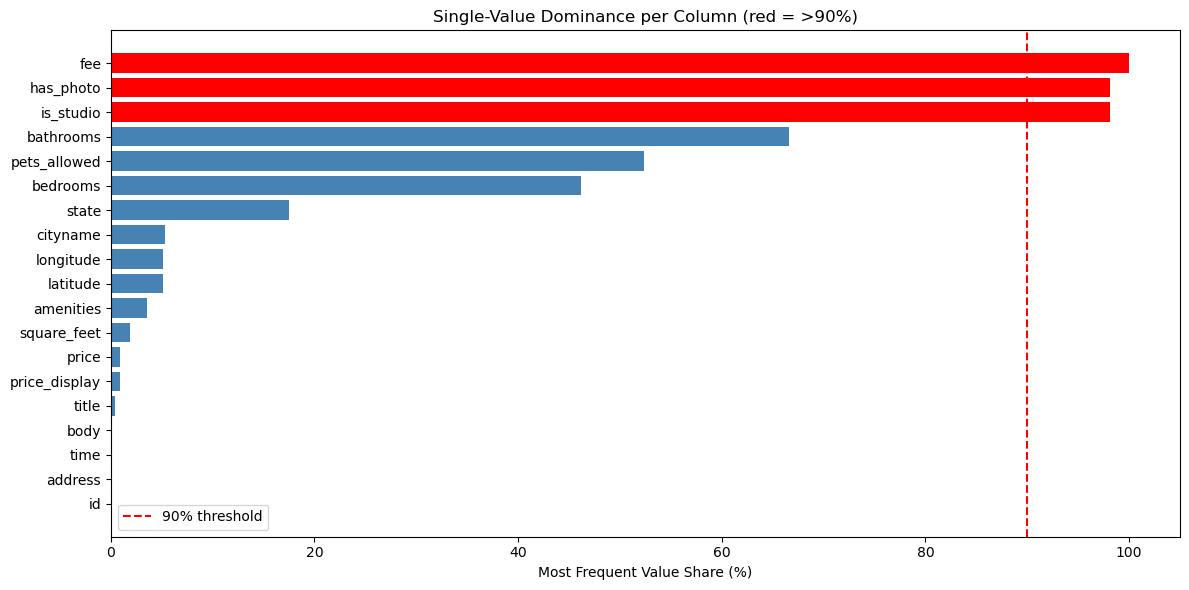

In [24]:
# Visualise: bar chart of single-value dominance per column
plt.figure(figsize=(12, 6))
colors = ['red' if v > 90 else 'steelblue' for v in dominance.values]
plt.barh(dominance.index, dominance.values, color=colors)
plt.axvline(x=90, color='red', linestyle='--', label='90% threshold')
plt.xlabel('Most Frequent Value Share (%)')
plt.title('Single-Value Dominance per Column (red = >90%)')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
# drop columns with more than 90% single-value dominance
# has_photo has 98% dominance but keeping for meaningful 2% variation
df.drop(columns=['fee','is_studio'], inplace=True)

dropping fee and is_studio, this specific feature remains way past the 90% red-line threshold, making it pretty much useless for finding patterns. It is essentially a constant, so removing it allows the analysis to focus on the other columns

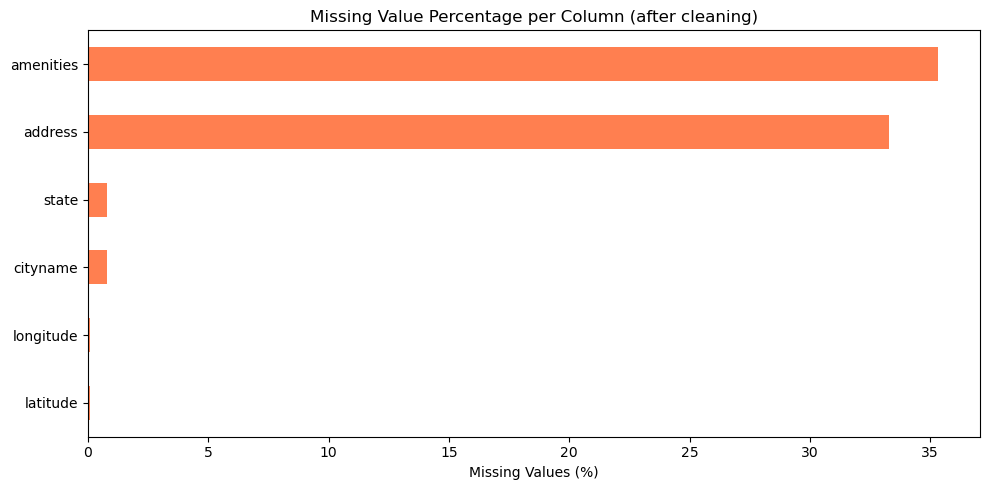

In [26]:
# Missing value % per column (bar chart)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 5))
missing_pct.plot(kind='barh', color='coral')
plt.xlabel('Missing Values (%)')
plt.title('Missing Value Percentage per Column (after cleaning)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [27]:
# High cardinality check for categorical columns
cat_cols = df.select_dtypes(include='object').columns
print("=== Unique values per categorical column ===")
for col in cat_cols:
    n = df[col].nunique()
    print(f"  {col}: {n} unique values")

print(f"\ncityname has {df['cityname'].nunique()} cities — will use top 20 or aggregate by state for modelling")
print(f"state has {df['state'].nunique()} states")

=== Unique values per categorical column ===
  title: 9308 unique values
  body: 9918 unique values
  amenities: 2247 unique values
  has_photo: 2 unique values
  pets_allowed: 4 unique values
  price_display: 1724 unique values
  address: 6629 unique values
  cityname: 1572 unique values
  state: 51 unique values

cityname has 1572 cities — will use top 20 or aggregate by state for modelling
state has 51 states


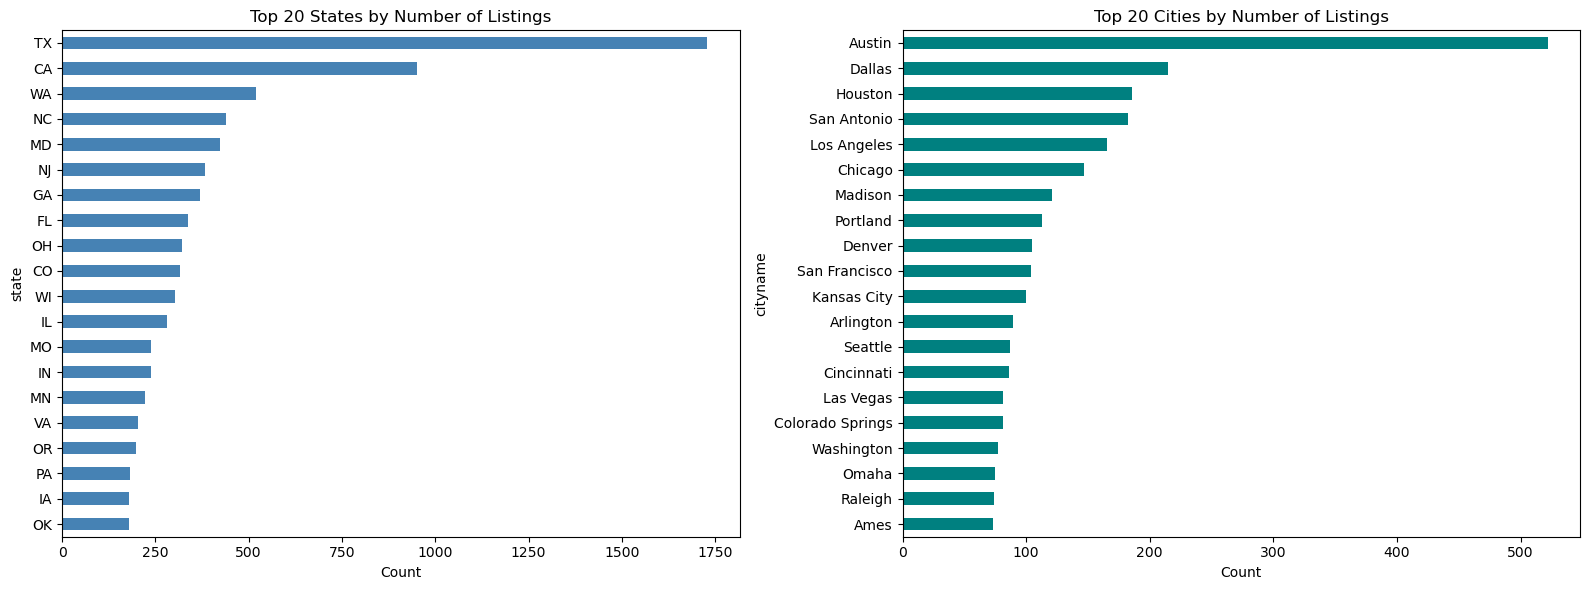

In [28]:
# Top 20 cities and states by listing count
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df['state'].value_counts().head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 States by Number of Listings')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

df['cityname'].value_counts().head(20).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 20 Cities by Number of Listings')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

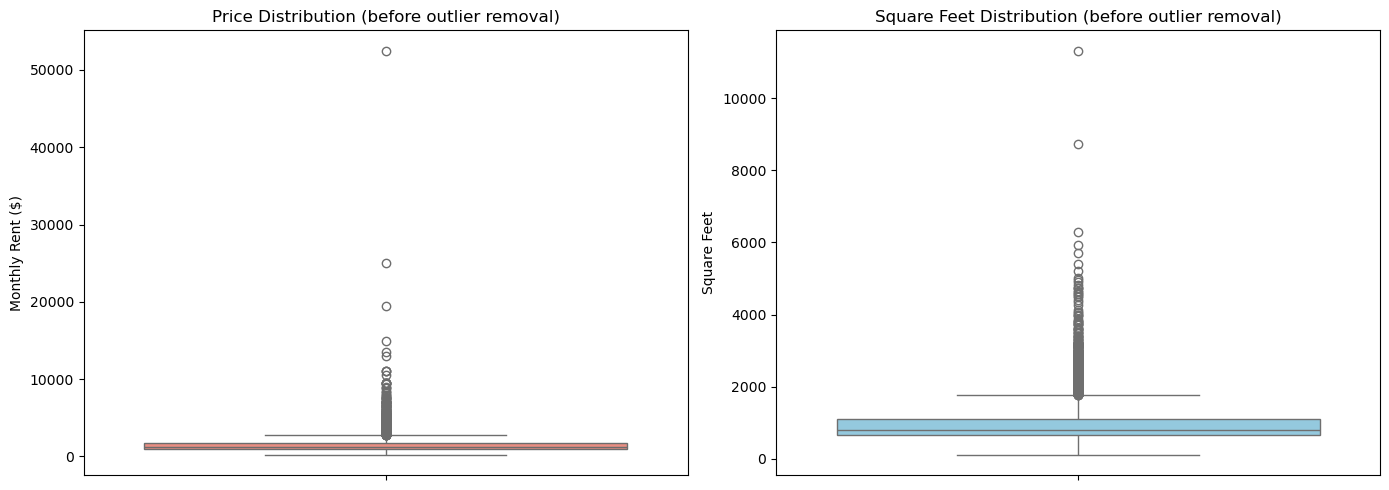

Shape before outlier removal: (9957, 17)


In [29]:
# Boxplots of price and square_feet BEFORE outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['price'], ax=axes[0], color='salmon')
axes[0].set_title('Price Distribution (before outlier removal)')
axes[0].set_ylabel('Monthly Rent ($)')

sns.boxplot(y=df['square_feet'], ax=axes[1], color='skyblue')
axes[1].set_title('Square Feet Distribution (before outlier removal)')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

print(f"Shape before outlier removal: {df.shape}")

In [30]:
# Remove outliers using IQR method for price and square_feet
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(dataframe)
    dataframe = dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]
    after = len(dataframe)
    print(f"  {column}: removed {before - after} rows  |  bounds: [{lower:.0f}, {upper:.0f}]")
    return dataframe

print("=== IQR Outlier Removal ===")
df = remove_outliers_iqr(df, 'price')
df = remove_outliers_iqr(df, 'square_feet')
print(f"\nShape after outlier removal: {df.shape}")

=== IQR Outlier Removal ===
  price: removed 615 rows  |  bounds: [-170, 2814]
  square_feet: removed 511 rows  |  bounds: [12, 1688]

Shape after outlier removal: (8831, 17)


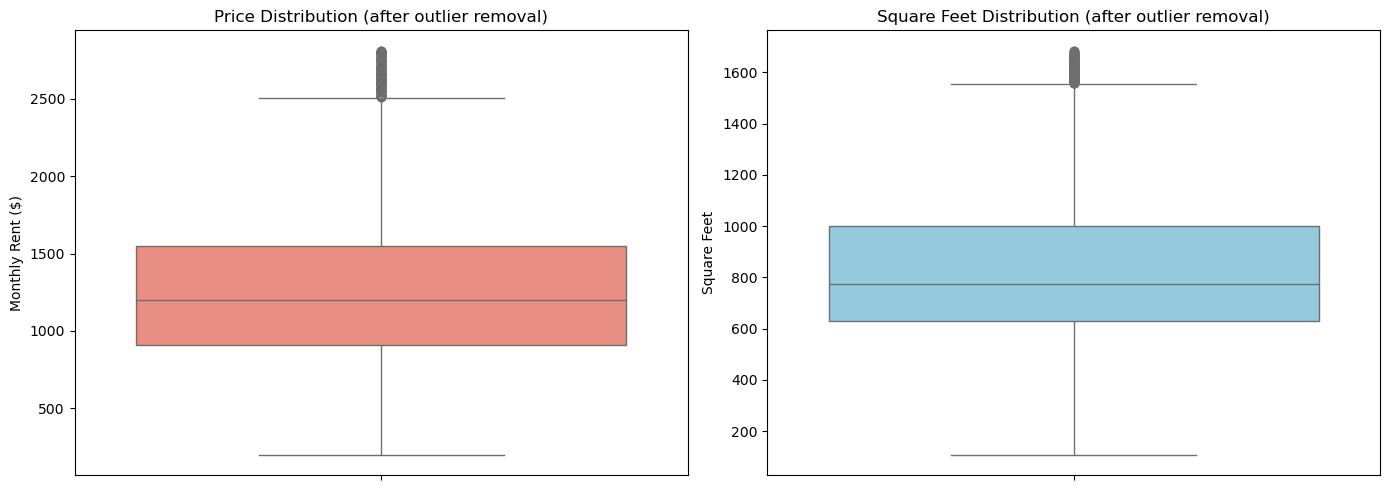

In [31]:
# Boxplots AFTER outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['price'], ax=axes[0], color='salmon')
axes[0].set_title('Price Distribution (after outlier removal)')
axes[0].set_ylabel('Monthly Rent ($)')

sns.boxplot(y=df['square_feet'], ax=axes[1], color='skyblue')
axes[1].set_title('Square Feet Distribution (after outlier removal)')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()

In [32]:
# we may need it later in the regression
df['log_price'] = np.log1p(df['price']) 

In [33]:
#  StandardScaler on numeric features (will be used later for PCA & clustering)
# working on anoter dataframe not the original one(df)
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Remove 'id' and 'time' from scaling — they are identifiers, not features
scale_cols = [c for c in numeric_cols if c not in ['id', 'time']]

scaler = StandardScaler()
df_scaled_preview = pd.DataFrame(scaler.fit_transform(df[scale_cols]), columns=scale_cols, index=df.index)

print("=== Scaled Features (first 5 rows) ===")
df_scaled_preview.head()

=== Scaled Features (first 5 rows) ===


,bathrooms,bedrooms,price,square_feet,latitude,longitude,log_price
2,-0.578734,-2.089125,0.224431,-2.457171,0.203344,1.112769,0.404111
3,-0.578734,-2.089125,-0.731494,-2.426348,1.770652,-1.868298,-0.682747
5,-0.578734,-2.089125,2.454923,-2.378403,0.539601,1.316561,1.944292
8,-0.578734,-2.089125,0.440285,-2.351005,0.000160,-1.875572,0.598488
14,-0.578734,-2.089125,0.851436,-2.172921,0.000160,-1.875572,0.933645


### Exploratory Data Analysis (EDA)


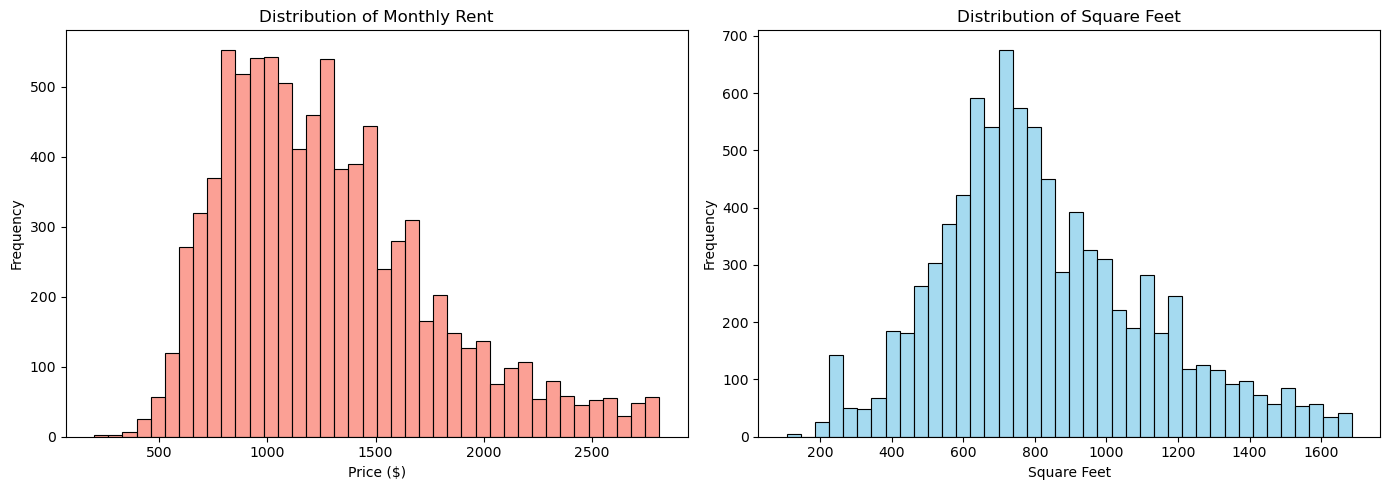

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price
sns.histplot(
    df['price'],
    bins=40,
    ax=axes[0],
    color='salmon',
    edgecolor='black'
)
axes[0].set_title('Distribution of Monthly Rent')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')

# Optional if skewed:
# axes[0].set_xscale('log')

# Square Feet
sns.histplot(
    df['square_feet'],
    bins=40,
    ax=axes[1],
    color='skyblue',
    edgecolor='black'
)
axes[1].set_title('Distribution of Square Feet')
axes[1].set_xlabel('Square Feet')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

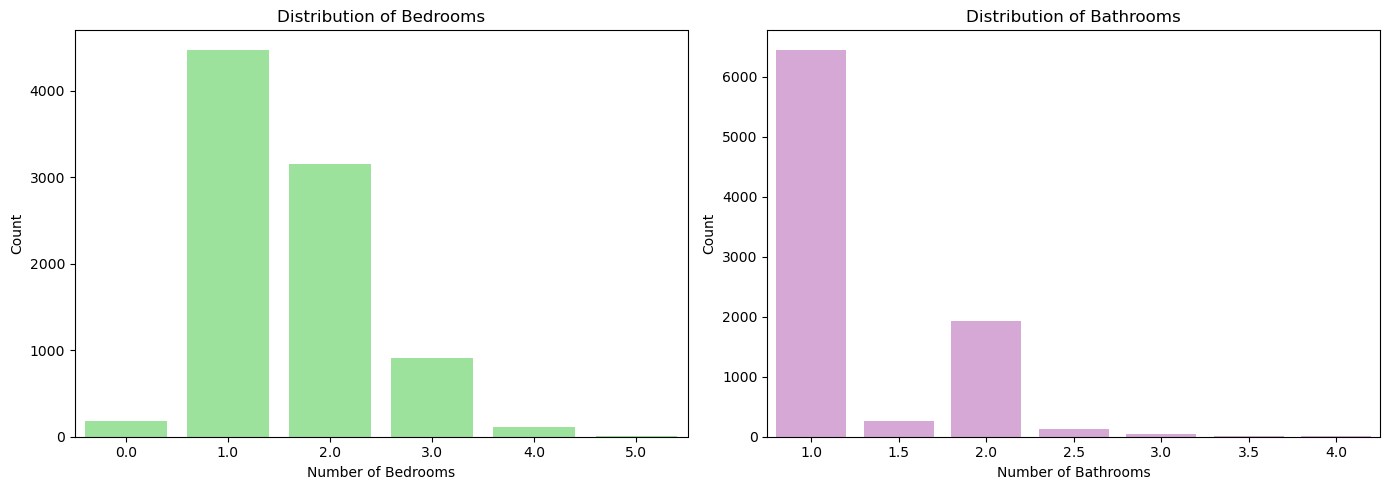

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bedrooms
sns.countplot(
    x='bedrooms',
    data=df,
    ax=axes[0],
    color='lightgreen'
)
axes[0].set_title('Distribution of Bedrooms')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Count')

# Bathrooms
sns.countplot(
    x='bathrooms',
    data=df,
    ax=axes[1],
    color='plum'
)
axes[1].set_title('Distribution of Bathrooms')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

1.5 bathrooms = 1 full bath (toilet + sink + shower/tub) + 1 half bath (toilet + sink only)

2.5 bathrooms = 2 full baths + 1 half bath

3.5 bathrooms = 3 full baths + 1 half bath

C:\Users\ahmed\AppData\Local\Temp\ipykernel_26412\1647425876.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\ahmed\AppData\Local\Temp\ipykernel_26412\1647425876.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


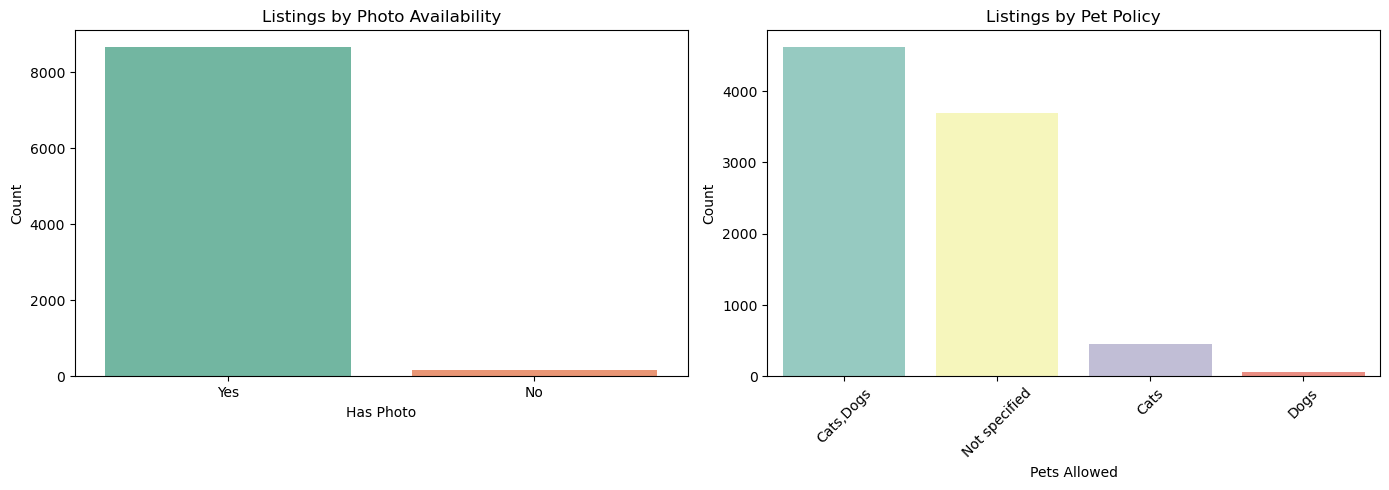

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Has Photo
sns.countplot(
    data=df,
    x='has_photo',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Listings by Photo Availability')
axes[0].set_xlabel('Has Photo')
axes[0].set_ylabel('Count')

# Pets Allowed
pets_order = df['pets_allowed'].value_counts().index
sns.countplot(
    data=df,
    x='pets_allowed',
    order=pets_order,
    ax=axes[1],
    palette='Set3'
)
axes[1].set_title('Listings by Pet Policy')
axes[1].set_xlabel('Pets Allowed')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

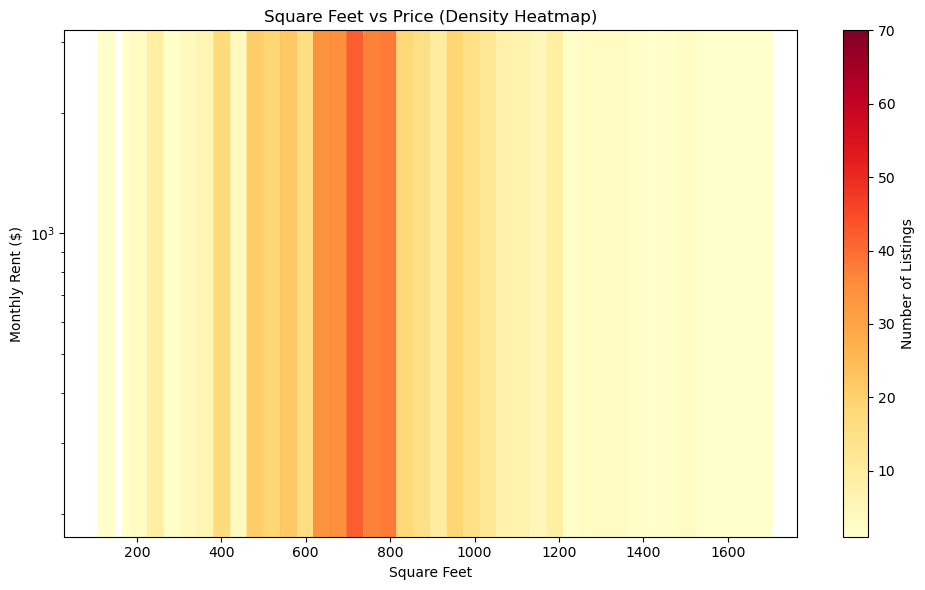

In [37]:
# Create price_per_sqft feature
df['price_per_sqft'] = df['price'] / df['square_feet']

# Remove infinite values if square_feet has zeros
df = df[df['square_feet'] > 0]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Hexbin plot (density-based visualization)
hb = ax.hexbin(
    df['square_feet'],
    df['price'],
    gridsize=40,           # more resolution
    cmap='YlOrRd',
    mincnt=1
)

# Labels and title
ax.set_xlabel('Square Feet')
ax.set_ylabel('Monthly Rent ($)')
ax.set_title('Square Feet vs Price (Density Heatmap)')

# Optional: log scale if price is skewed
ax.set_yscale('log')

# Colorbar
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Number of Listings')

plt.tight_layout()
plt.show()


The heatmap shows that most rental listings are concentrated between 600 and 800 square feet, which creates the bright orange vertical "heat" zone. Even for apartments of the same size, there is a very wide range of monthly rent prices available across the market. The layout makes it easy to spot outliers, such as small units that are unusually expensive or large units with surprisingly low rent

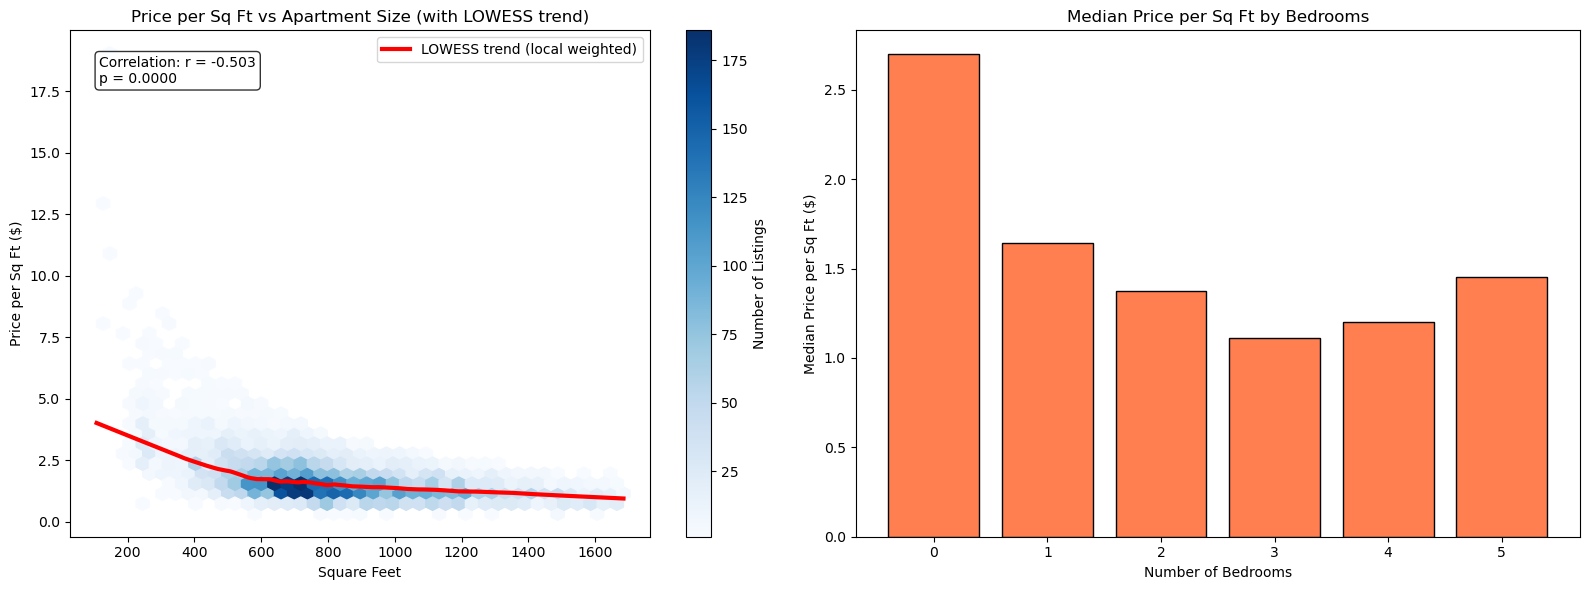

In [38]:
# Remove invalid values first
df = df[(df['square_feet'] > 0) & (df['price_per_sqft'] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------
# 1) Hexbin Plot with LOWESS curve (non-linear trend)
# -------------------------
from scipy.stats import pearsonr
from statsmodels.nonparametric.smoothers_lowess import lowess

hb = axes[0].hexbin(
    df['square_feet'],
    df['price_per_sqft'],
    gridsize=40,
    cmap='Blues',
    mincnt=1
)

axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Price per Sq Ft ($)')
axes[0].set_title('Price per Sq Ft vs Apartment Size (with LOWESS trend)')

# LOWESS curve (flexible, non-linear trend following the data)
lowess_result = lowess(df['price_per_sqft'], df['square_feet'], frac=0.1)
axes[0].plot(
    lowess_result[:, 0],
    lowess_result[:, 1],
    'r-',
    linewidth=3,
    label='LOWESS trend (local weighted)'
)

# Calculate correlation only
r_value, p_value = pearsonr(df['square_feet'], df['price_per_sqft'])

axes[0].legend()
axes[0].text(
    0.05, 0.95,
    f'Correlation: r = {r_value:.3f}\np = {p_value:.4f}',
    transform=axes[0].transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

cb = fig.colorbar(hb, ax=axes[0])
cb.set_label('Number of Listings')


# -------------------------
# 2) Median Price per Sqft by Bedrooms
# -------------------------
median_ppsf_bedrooms = (
    df.groupby('bedrooms')['price_per_sqft']
    .median()
    .reset_index()
)

axes[1].bar(
    median_ppsf_bedrooms['bedrooms'],
    median_ppsf_bedrooms['price_per_sqft'],
    color='coral',
    edgecolor='black'
)

axes[1].set_xlabel('Number of Bedrooms')
axes[1].set_ylabel('Median Price per Sq Ft ($)')
axes[1].set_title('Median Price per Sq Ft by Bedrooms')

plt.tight_layout()
plt.show()




The red LOWESS curve is a much better fit because it follows the natural bend of the data instead of forcing a straight line. It clearly shows that the price for each square foot starts very high for tiny apartments but drops quickly as the units get bigger. Most listings are clustered in the middle, where the price finally starts to level out and become more consistent. This chart proves that while larger apartments cost more total, you actually get a better deal on the price per square foot as the size increases.


The bar chart shows that median price per square foot is highest for studios (0 bedrooms) and drops significantly as the bedroom count increases. The cost hits its lowest point at 3 bedrooms, but starts to climb again for 4 and 5-bedroom units. This confirms that smaller apartments are the most expensive per foot, while mid-sized family homes offer the best value. The slight rise for 5-bedroom units likely reflects a premium for rare, luxury-sized properties in the market.

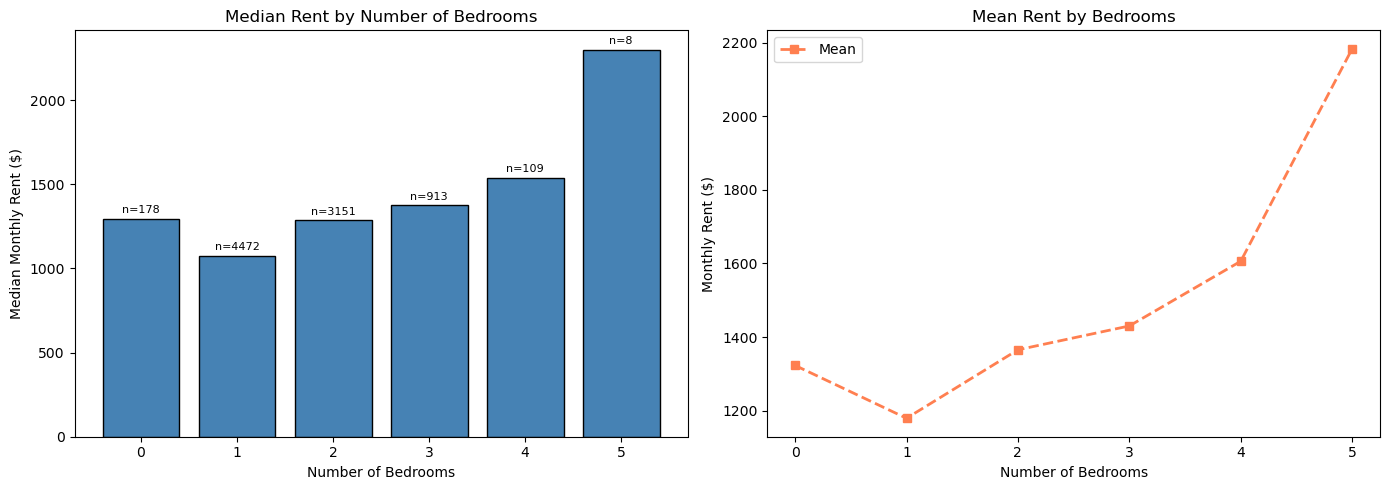

In [39]:
# Median price per number of bedrooms (line/bar chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: median price by bedrooms
median_price_bed = df.groupby('bedrooms')['price'].agg(['median', 'mean', 'count']).reset_index()
bars = axes[0].bar(median_price_bed['bedrooms'], median_price_bed['median'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Median Monthly Rent ($)')
axes[0].set_title('Median Rent by Number of Bedrooms')
# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, median_price_bed['count'])):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'n={int(count)}', 
                 ha='center', va='bottom', fontsize=8)

# Line chart: median and mean price by bedrooms
axes[1].plot(median_price_bed['bedrooms'], median_price_bed['mean'], marker='s', label='Mean', linewidth=2, color='coral', linestyle='--')
axes[1].set_xlabel('Number of Bedrooms')
axes[1].set_ylabel('Monthly Rent ($)')
axes[1].set_title('Mean Rent by Bedrooms')
axes[1].legend()

plt.tight_layout()
plt.show()

The total monthly rent shows a surprising trend where studios actually cost more than one-bedroom apartments on average. Once past the one-bedroom mark, the price starts to climb steadily for every extra bedroom included in the unit. There is a major price jump for five-bedroom homes, likely because these large properties are rare and cater to the high-end market. 

Note: most of the apartments with 1 bedroom

### Bivariate Analysis — Categorical
Boxplots showing price distributions across categorical variables.

C:\Users\ahmed\AppData\Local\Temp\ipykernel_26412\1203897384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


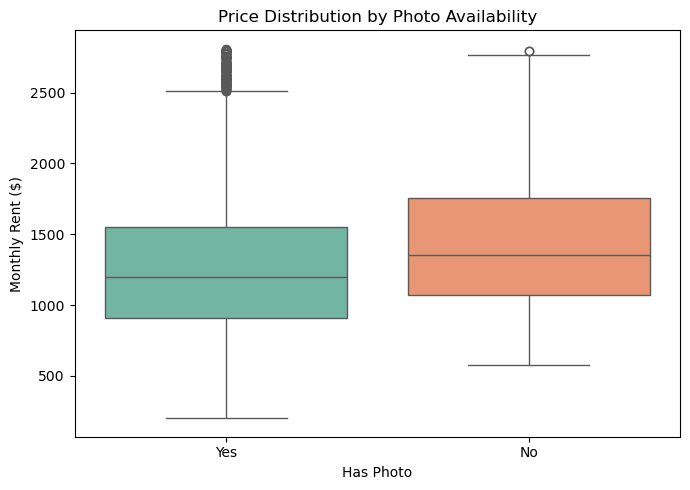

In [40]:
# Price by has_photo
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='has_photo',
    y='price',
    palette='Set2'
)

plt.title('Price Distribution by Photo Availability')
plt.xlabel('Has Photo')
plt.ylabel('Monthly Rent ($)')

plt.tight_layout()
plt.show()



photo presence doesn't automatically guarantee a higher rental price.

### Geographic Analysis
Which states and cities have the highest rents?

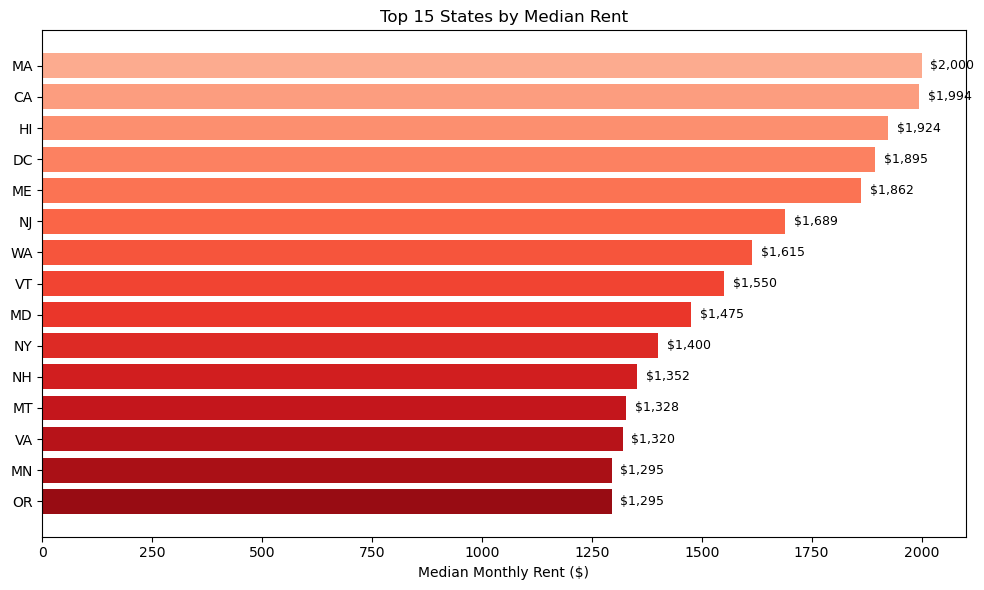

In [41]:
# Top 15 States by median rent
state_median = df.groupby('state')['price'].median().sort_values(ascending=False).head(15)
colors_state = plt.cm.Reds(np.linspace(0.3, 0.9, len(state_median)))

plt.figure(figsize=(10, 6))
plt.barh(state_median.index[::-1], state_median.values[::-1], color=colors_state[::-1])
plt.xlabel('Median Monthly Rent ($)')
plt.title('Top 15 States by Median Rent')

# Annotate values
for i, (state, val) in enumerate(zip(state_median.index[::-1], state_median.values[::-1])):
    plt.text(val + 20, i, f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()



In [43]:
import plotly.express as px
    # Calculate mean rent by state
state_rent = df.groupby('state')['price'].mean().reset_index()
state_rent.columns = ['state', 'avg_rent']
    
fig = px.choropleth(
        state_rent,
        locations='state',
        locationmode='USA-states',
        color='avg_rent',
        color_continuous_scale='Reds',
        scope='usa',
        title='Average Monthly Rent by State',
        labels={'avg_rent': 'Avg Rent ($)'}
    )
fig.update_layout(geo=dict(bgcolor='rgba(0,0,0,0)'))
fig.show()

The rent map and bar chart show that where you live is a huge deal for your wallet. Massachusetts and California are the most expensive, with middle-range rents hitting about $2,000, while Hawaii and DC aren't far behind. On the other hand, a lot of states in the middle of the country are much cheaper, often staying well under $1,000. Basically, you can pay twice as much for a place just by crossing into a different state.

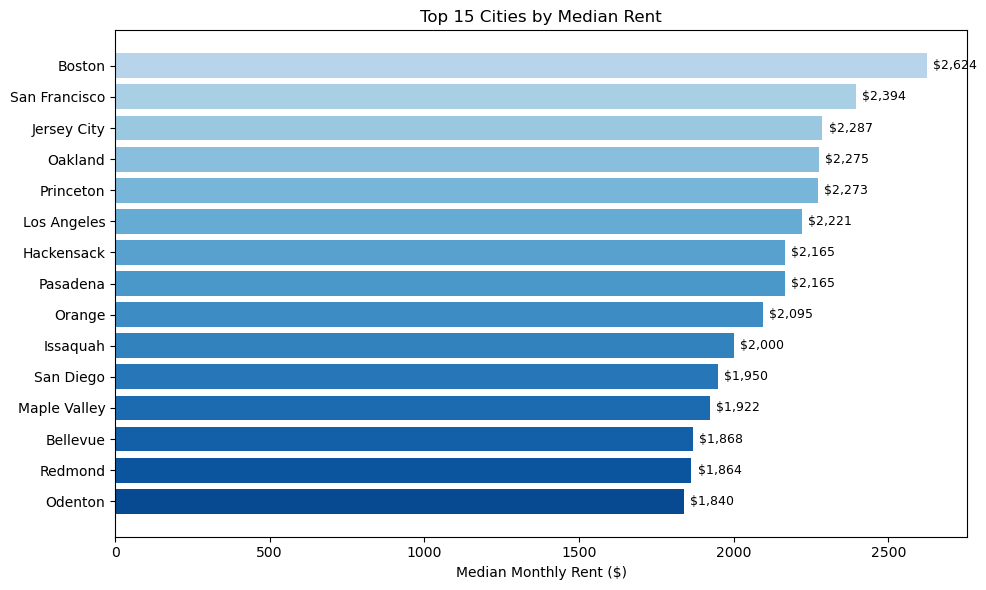

In [44]:
# Filter cities with at least 10 listings
city_counts = df['cityname'].value_counts()
cities_min10 = city_counts[city_counts >= 10].index
df_filtered = df[df['cityname'].isin(cities_min10)]

# Top 15 Cities by median rent
city_median = df_filtered.groupby('cityname')['price'].median().sort_values(ascending=False).head(15)
colors_city = plt.cm.Blues(np.linspace(0.3, 0.9, len(city_median)))

plt.figure(figsize=(10, 6))
plt.barh(city_median.index[::-1], city_median.values[::-1], color=colors_city[::-1])
plt.xlabel('Median Monthly Rent ($)')
plt.title('Top 15 Cities by Median Rent')

# Annotate values
for i, (city, val) in enumerate(zip(city_median.index[::-1], city_median.values[::-1])):
    plt.text(val + 20, i, f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

While individual cities like Boston and San Francisco have the highest rents, they also drive up the overall cost of their states. Because Boston is so expensive, it helps push Massachusetts to the #1 spot on the state list with a $2,000 median rent. Similarly, the high costs in San Francisco, Los Angeles, and San Diego make California the second most expensive state at $1,994. Essentially, these "expensive" states aren't pricey everywhere; they are being pulled up by a handful of high-demand cities that charge a massive premium.

In [45]:
# Extract time features 
df['listing_date'] = pd.to_datetime(df['time'], unit='s')
df['listing_year'] = df['listing_date'].dt.year
df['listing_month'] = df['listing_date'].dt.month
df['listing_yearmonth'] = df['listing_date'].dt.to_period('M')

print("=== Temporal Coverage ===")
print(f"Earliest listing: {df['listing_date'].min()}")
print(f"Latest listing: {df['listing_date'].max()}")
time_span = (df['listing_date'].max() - df['listing_date'].min()).days
print(f"Time span: {time_span} days (~{time_span/30:.1f} months)")

=== Temporal Coverage ===
Earliest listing: 2019-09-17 18:12:56
Latest listing: 2019-12-26 12:09:01
Time span: 99 days (~3.3 months)


Dataset covers only ~4 months — insufficient for seasonality analysis

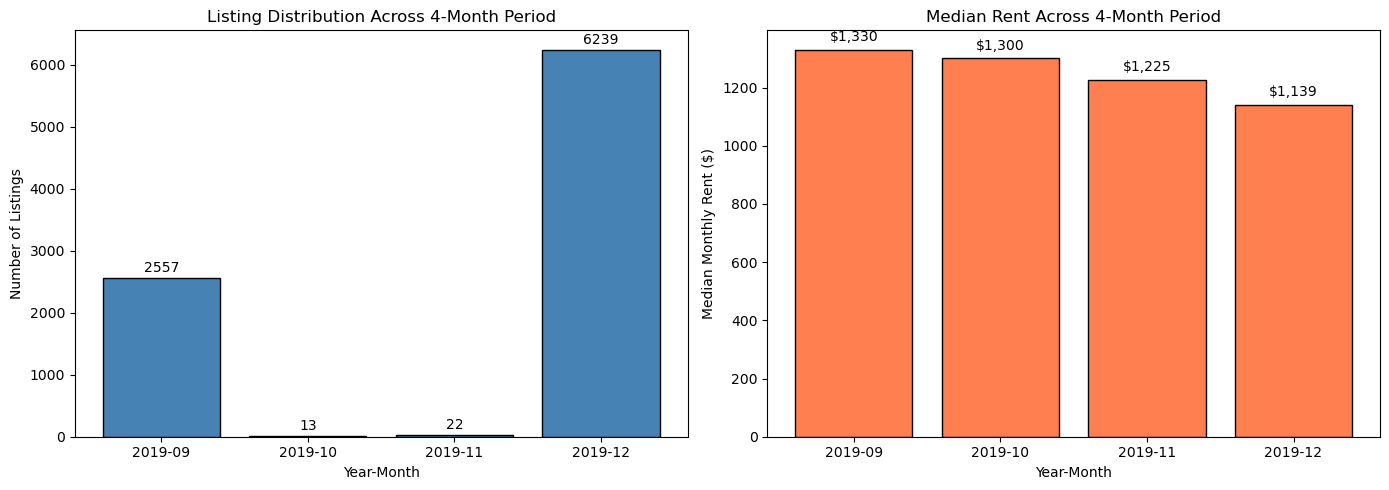


No seasonality analysis performed — insufficient temporal coverage.
Prices appear relatively stable across this 4-month window.


In [46]:
# Simple visualization of the 4-month snapshot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Listings by year-month (only the months we have)
listings_by_month = df.groupby('listing_yearmonth').size().sort_index()
axes[0].bar(range(len(listings_by_month)), listings_by_month.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(listings_by_month)))
axes[0].set_xticklabels([str(m) for m in listings_by_month.index], rotation=0)
axes[0].set_xlabel('Year-Month')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Listing Distribution Across 4-Month Period')
for i, v in enumerate(listings_by_month.values):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=10)

# Median price by year-month
median_price_by_month = df.groupby('listing_yearmonth')['price'].median().sort_index()
axes[1].bar(range(len(median_price_by_month)), median_price_by_month.values, color='coral', edgecolor='black')
axes[1].set_xticks(range(len(median_price_by_month)))
axes[1].set_xticklabels([str(m) for m in median_price_by_month.index], rotation=0)
axes[1].set_xlabel('Year-Month')
axes[1].set_ylabel('Median Monthly Rent ($)')
axes[1].set_title('Median Rent Across 4-Month Period')
for i, v in enumerate(median_price_by_month.values):
    axes[1].text(i, v + 20, f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


print(f"\nNo seasonality analysis performed — insufficient temporal coverage.")
print(f"Prices appear relatively stable across this 4-month window.")

###  Correlation Analysis


Columns included in correlation analysis: ['bathrooms', 'bedrooms', 'price', 'square_feet', 'latitude', 'longitude']
Excluded: ['id', 'time', 'price_per_sqft']


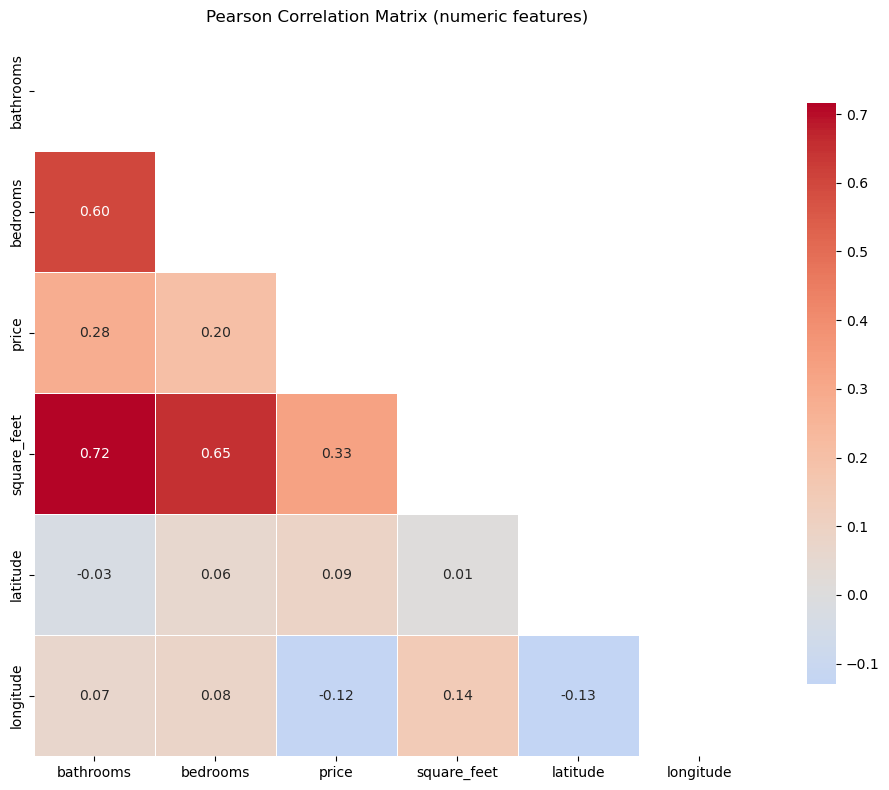

In [ ]:
# ── Pearson correlation matrix among all numeric features ──────────────────
numeric_cols_corr = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols_corr.remove('log_price')

# Exclude:
#   - identifiers / derived date columns (no analytical meaning)
#   - price_per_sqft: derived directly from price ÷ square_feet → its
#     correlation with price is algebraically inflated and not informative
#     as an independent predictor signal
exclude = ['id', 'time', 'listing_year', 'listing_month', 'price_per_sqft']
corr_cols = [c for c in numeric_cols_corr if c not in exclude]

print(f"Columns included in correlation analysis: {corr_cols}")
print(f"Excluded: {[c for c in numeric_cols_corr if c in exclude]}")

pearson_matrix = df[corr_cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(pearson_matrix, dtype=bool))   # upper triangle mask
sns.heatmap(
    pearson_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Pearson Correlation Matrix (numeric features)')
plt.tight_layout()
plt.show()


### 6.2 ANOVA — Does mean rent differ by state and by number of bedrooms?

**Before running ANOVA we check its two key assumptions:**
1. Normality of residuals within each group (Shapiro-Wilk)
2. Homogeneity of variance across groups (Levene's test)

If either assumption fails we fall back to the non-parametric **Kruskal-Wallis** test.


In [ ]:
# ── Assumption 1: Normality — Shapiro-Wilk per bedroom group ──────────────
# Shapiro-Wilk is limited to n ≤ 5 000; we sample per group when needed
from scipy.stats import shapiro, levene

bedroom_groups = {}
print("=== Shapiro-Wilk Normality Test per Bedroom Group ===")
print(f"{'Bedrooms':>10} {'n':>6} {'W':>8} {'p-value':>10} {'Normal?':>10}")
print("-" * 50)

for bed, grp in df.groupby('bedrooms')['price']:
    sample = grp.sample(min(len(grp), 5000), random_state=42)
    w, p = shapiro(sample)
    bedroom_groups[bed] = grp.values
    normal = "YES" if p > 0.05 else "NO"
    print(f"{bed:>10} {len(grp):>6} {w:>8.4f} {p:>10.4f} {normal:>10}")

# Q-Q plots for the 4 most common bedroom counts
common_beds = df['bedrooms'].value_counts().head(4).index.sort_values()
fig, axes = plt.subplots(1, len(common_beds), figsize=(5 * len(common_beds), 4))
for ax, bed in zip(axes, common_beds):
    sample = df[df['bedrooms'] == bed]['price'].sample(min(500, (df['bedrooms'] == bed).sum()), random_state=42)
    stats.probplot(sample, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot — {bed} bedroom(s)\n(n={len(sample)})')
plt.suptitle('Normality Check: Q-Q Plots by Bedrooms', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# ── Assumption 2: Homogeneity of Variance — Levene's Test ─────────────────
groups_bed   = [grp for _, grp in df.groupby('bedrooms')['price']]
stat_bed, p_bed = levene(*groups_bed)
print("=== Levene's Test — Price by Bedrooms ===")
print(f"  Levene statistic = {stat_bed:.4f},  p = {p_bed:.6f}")
print(f"  Homogeneity of variance: {'HOLDS (p>0.05)' if p_bed > 0.05 else 'VIOLATED (p≤0.05)'}")

# Top 15 states for the state-level test (too many groups otherwise)
top15_states = df['state'].value_counts().head(15).index
df_top15 = df[df['state'].isin(top15_states)]
groups_state = [grp for _, grp in df_top15.groupby('state')['price']]
stat_st, p_st = levene(*groups_state)
print("\n=== Levene's Test — Price by State (top 15) ===")
print(f"  Levene statistic = {stat_st:.4f},  p = {p_st:.6f}")
print(f"  Homogeneity of variance: {'HOLDS (p>0.05)' if p_st > 0.05 else 'VIOLATED (p≤0.05)'}")

print("\n→ Both normality (Shapiro-Wilk) and homogeneity of variance (Levene) are checked.")
print("  If either fails, we proceed with the non-parametric Kruskal-Wallis test.")


In [ ]:
# ── Kruskal-Wallis Test (non-parametric ANOVA alternative) ─────────────────
from scipy.stats import kruskal, f_oneway

# --- By Bedrooms ---
kw_stat_bed, kw_p_bed = kruskal(*groups_bed)
print("=== Kruskal-Wallis Test: Price ~ Bedrooms ===")
print(f"  H = {kw_stat_bed:.4f},  p = {kw_p_bed:.2e}")
print(f"  Result: {'Significant difference (p<0.05)' if kw_p_bed < 0.05 else 'No significant difference'}")

# For comparison: one-way ANOVA result
f_stat_bed, f_p_bed = f_oneway(*groups_bed)
print(f"\n  (One-way ANOVA F = {f_stat_bed:.4f},  p = {f_p_bed:.2e}  — shown for reference only)")

# --- By State (top 15) ---
kw_stat_st, kw_p_st = kruskal(*groups_state)
print("\n=== Kruskal-Wallis Test: Price ~ State (top 15) ===")
print(f"  H = {kw_stat_st:.4f},  p = {kw_p_st:.2e}")
print(f"  Result: {'Significant difference (p<0.05)' if kw_p_st < 0.05 else 'No significant difference'}")

# Visualise the distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplot: price by bedrooms
sns.boxplot(data=df, x='bedrooms', y='price', palette='Set2', ax=axes[0])
axes[0].set_title(f'Price by Number of Bedrooms\n(Kruskal-Wallis H={kw_stat_bed:.1f}, p={kw_p_bed:.2e})')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Monthly Rent ($)')

# Boxplot: price by top-15 states
state_order = df_top15.groupby('state')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top15, x='state', y='price', order=state_order, palette='coolwarm', ax=axes[1])
axes[1].set_title(f'Price by State (top 15)\n(Kruskal-Wallis H={kw_stat_st:.1f}, p={kw_p_st:.2e})')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Monthly Rent ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 6.3 Post-hoc Analysis — Tukey HSD

Tukey's Honest Significant Difference test identifies **which specific pairs** of groups differ significantly in rent. Even though normality is violated, Tukey HSD is used here as a descriptive post-hoc tool alongside the Kruskal-Wallis result to visualise the mean ± CI per group.


In [ ]:
# ── Tukey HSD — Price by Bedrooms ─────────────────────────────────────────
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings

# --- By Bedrooms ---
tukey_bed = pairwise_tukeyhsd(endog=df['price'], groups=df['bedrooms'], alpha=0.05)

# Summary table (first 20 pairs)
tukey_bed_df = pd.DataFrame(
    data=tukey_bed.summary().data[1:],
    columns=tukey_bed.summary().data[0]
)
print("=== Tukey HSD — Price by Bedrooms (all pairs) ===")
print(tukey_bed_df.to_string(index=False))

# Mean ± CI plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bedrooms — mean ± CI
bed_stats = df.groupby('bedrooms')['price'].agg(['mean', 'sem', 'count']).reset_index()
bed_stats['ci95'] = 1.96 * bed_stats['sem']

axes[0].errorbar(
    bed_stats['bedrooms'], bed_stats['mean'],
    yerr=bed_stats['ci95'], fmt='o-', capsize=5,
    color='steelblue', linewidth=2, markersize=8
)
axes[0].fill_between(
    bed_stats['bedrooms'],
    bed_stats['mean'] - bed_stats['ci95'],
    bed_stats['mean'] + bed_stats['ci95'],
    alpha=0.2, color='steelblue'
)
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Mean Monthly Rent ($)')
axes[0].set_title('Mean Rent ± 95% CI by Bedrooms\n(Tukey HSD post-hoc)')
axes[0].set_xticks(bed_stats['bedrooms'])

# States — mean ± CI 
state_stats = df_top15.groupby('state')['price'].agg(['mean', 'sem']).reset_index()
state_stats['ci95'] = 1.96 * state_stats['sem']
state_stats = state_stats.sort_values('mean', ascending=False)

axes[1].errorbar(
    range(len(state_stats)), state_stats['mean'],
    yerr=state_stats['ci95'], fmt='o', capsize=5,
    color='coral', linewidth=2, markersize=8
)
axes[1].set_xticks(range(len(state_stats)))
axes[1].set_xticklabels(state_stats['state'], rotation=45, ha='right')
axes[1].set_ylabel('Mean Monthly Rent ($)')
axes[1].set_title('Mean Rent ± 95% CI by State (top 15)\n(Tukey HSD post-hoc)')

plt.tight_layout()
plt.show()


In [ ]:
# ── Tukey HSD — Price by State (top 15) ───────────────────────────────────
tukey_state = pairwise_tukeyhsd(endog=df_top15['price'], groups=df_top15['state'], alpha=0.05)
tukey_state_df = pd.DataFrame(
    data=tukey_state.summary().data[1:],
    columns=tukey_state.summary().data[0]
)
# Show only pairs that are significantly different
sig_pairs = tukey_state_df[tukey_state_df['reject'] == True]
print(f"=== Tukey HSD — Price by State (significant pairs only) ===")
print(f"Total pairs tested: {len(tukey_state_df)}")
print(f"Significantly different pairs (p_adj < 0.05): {len(sig_pairs)}")
print(sig_pairs[['group1','group2','meandiff','p-adj','lower','upper','reject']].head(20).to_string(index=False))


In [ ]:
# ── Residuals Diagnostics for ANOVA (bedrooms) ────────────────────────────
# Compute group means → residuals = price - group_mean
df['group_mean_bed'] = df.groupby('bedrooms')['price'].transform('mean')
df['residuals_anova'] = df['price'] - df['group_mean_bed']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram of residuals
axes[0].hist(df['residuals_anova'], bins=50, color='steelblue', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of ANOVA Residuals (bedrooms)')

# Q-Q plot of residuals
stats.probplot(df['residuals_anova'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of ANOVA Residuals')

# Fitted vs Residuals
axes[2].scatter(df['group_mean_bed'], df['residuals_anova'],
                alpha=0.2, s=5, color='coral')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Fitted (Group Mean)')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Fitted vs Residuals Plot')

plt.tight_layout()
plt.show()

# Clean up temp columns
df.drop(columns=['group_mean_bed', 'residuals_anova'], inplace=True)


### 6.4 Collinearity Check — VIF & Chi-Square

Before building the regression model we need to ensure predictors are not too correlated with each other.
- **VIF > 10**: high multicollinearity — consider dropping
- **VIF 5–10**: moderate concern — monitor
- **Chi-Square**: checks association between pairs of categorical predictors


In [ ]:
# ── VIF for numeric predictors ─────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Select numeric predictors (exclude target, log_price, and identifiers)
vif_cols = [c for c in corr_cols if c not in ['price', 'log_price', 'id', 'time']]
X_vif = df[vif_cols].dropna()
X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    'feature': vif_cols,
    'VIF': [variance_inflation_factor(X_vif_const.values, i + 1)
            for i in range(len(vif_cols))]
}).sort_values('VIF', ascending=False)

print("=== Variance Inflation Factor (VIF) ===")
print(vif_data.to_string(index=False))
print("\nVIF > 10  → High multicollinearity (consider dropping)")
print("VIF 5–10 → Moderate concern")
print("VIF < 5  → Acceptable")

# Bar chart of VIF
plt.figure(figsize=(9, 5))
colors_vif = ['crimson' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in vif_data['VIF']]
plt.barh(vif_data['feature'][::-1], vif_data['VIF'][::-1], color=colors_vif[::-1], edgecolor='black')
plt.axvline(x=5,  color='orange', linestyle='--', label='VIF = 5 (moderate)')
plt.axvline(x=10, color='crimson', linestyle='--', label='VIF = 10 (high)')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor per Numeric Predictor')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ── Chi-Square between pairs of categorical predictors ─────────────────────
from scipy.stats import chi2_contingency
import itertools

cat_pred_cols = ['has_photo', 'pets_allowed']   # main categoricals for modelling
results_chi2 = []

for col1, col2 in itertools.combinations(cat_pred_cols, 2):
    ct = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    results_chi2.append({
        'pair': f'{col1} × {col2}',
        'chi2': round(chi2, 4),
        'p_value': round(p, 6),
        'dof': dof,
        "Cramér's V": round(cramers_v, 4),
        'Associated?': 'YES' if p < 0.05 else 'NO'
    })

chi2_result_df = pd.DataFrame(results_chi2)
print("=== Chi-Square Test — Categorical Predictor Pairs ===")
print(chi2_result_df.to_string(index=False))
print("\nCramér's V interpretation: <0.1 negligible | 0.1–0.3 weak | 0.3–0.5 moderate | >0.5 strong")

# Contingency heatmap for has_photo × pets_allowed
ct_hp = pd.crosstab(df['has_photo'], df['pets_allowed'], normalize='index') * 100
plt.figure(figsize=(8, 4))
sns.heatmap(ct_hp, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5,
            cbar_kws={'label': 'Row % share'})
plt.title('Contingency Heatmap: has_photo × pets_allowed\n(row-normalised %)')
plt.ylabel('Has Photo')
plt.xlabel('Pets Allowed')
plt.tight_layout()
plt.show()
